# Giai đoạn 3 — Tách train / test và dựng fold

```
┌──────────────────────────────────────────────────────────────────────┐
│                           03_TachTrainTest                           │
└──────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 01_LamSachKhaoSat/khaosat_sach.csv  —  676 phiếu sạch
         │
         ▼
  XỬ LÝ
    1. Tách 85 / 15 phân tầng theo NGÀNH (không phải theo khối)
    2. Kiểm tra đủ 39 ngành có mặt ở cả hai phía
    3. Dựng RepeatedStratifiedKFold 5×3 = 15 fold trên phần train
    4. KHOÁ tập test lại — không giai đoạn nào từ 4 đến 9 được mở
         │
         ▼
  ĐẦU RA
    • 03_TachTrainTest/khaosat_train.csv
    • 03_TachTrainTest/khaosat_test_KHOA.csv   ← chỉ mở ở Giai đoạn 10
    • 03_TachTrainTest/cv_folds.json
    • 03_TachTrainTest/hinh_3_*.png            —  2 hình
```

## Vì sao tách TRƯỚC khi làm bất cứ việc gì khác

Đây là bước quyết định tính trung thực của toàn bộ con số cuối cùng.

Mọi thứ về sau — học phân phối Likert, sinh dữ liệu bằng GA, tinh chỉnh siêu tham số — đều **chỉ
được nhìn 574 phiếu train**. Nếu GA học phân phối từ cả 676 phiếu rồi mô hình được chấm điểm trên
102 phiếu test, thì test đã gián tiếp tham gia huấn luyện và con số báo cáo sẽ cao giả.

## Vì sao phân tầng theo NGÀNH

Ngành ít nhất chỉ có 6 phiếu. Tách ngẫu nhiên thuần thì rất dễ có ngành rơi hết vào một phía — lúc
đó hoặc mô hình không bao giờ học được ngành đó, hoặc không bao giờ được kiểm tra trên nó.

Phân tầng theo ngành đảm bảo **mỗi ngành đều xuất hiện ở cả hai phía** theo đúng tỉ lệ 85/15.

## Vì sao 15 fold thay vì 5

574 dòng là ít. Với 5 fold, mỗi lần đo chỉ dựa trên ~115 dòng validation, nên con số dao động mạnh
giữa các lần chạy — chênh 2-3 điểm là chuyện thường, và ta không phân biệt được đâu là cải tiến
thật đâu là may rủi.

`RepeatedStratifiedKFold(5, n_repeats=3)` lặp lại việc chia 5 fold ba lần với ba cách xáo khác nhau
→ **15 lần đo**, gộp lại cho con số ổn định hơn hẳn.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Web gửi limit=3 (web/src/app/(main)/predict/page.tsx) nên Top-3 là chỉ tiêu
# chính; Top-1/2/5 báo cáo kèm để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_TachTrainTest",
    4: "04_MocChuan",
    5: "05_HocPhanPhoi",
    6: "06_GA_TangCuong",
    7: "07_KiemDinhGA",
    8: "08_TrainFinal",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold

OUT = thu_muc(3)
TI_LE_TEST = 0.15
N_SPLITS, N_REPEATS = 5, 3

M = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
MA_TO_TEN = {int(k): v for k, v in M["ma_to_ten"].items()}
NHOM = {int(k): v for k, v in M["nganh_to_nhom"].items()}
TEN_NHOM = {int(k): v for k, v in M["ten_nhom"].items()}

d = pd.read_csv(thu_muc(1) / "khaosat_sach.csv")
print(f"Đọc {len(d)} phiếu sạch · {d.ma_nganh.nunique()} ngành")
print(f"Ngành ít phiếu nhất: {d.ma_nganh.value_counts().min()} phiếu")

Đọc 676 phiếu sạch · 39 ngành
Ngành ít phiếu nhất: 6 phiếu


## 1. Tách 85 / 15

In [2]:
tr, te = train_test_split(d, test_size=TI_LE_TEST, random_state=SEED,
                          stratify=d.ma_nganh)
tr = tr.sort_index().reset_index(drop=True)
te = te.sort_index().reset_index(drop=True)

assert len(tr) + len(te) == len(d)
assert tr.ma_nganh.nunique() == 39, "train thiếu ngành"
assert te.ma_nganh.nunique() == 39, "test thiếu ngành"

print(f"TRAIN : {len(tr):3d} phiếu  ({len(tr)/len(d):.1%})  ·"
      f" {tr.ma_nganh.nunique()}/39 ngành")
print(f"TEST  : {len(te):3d} phiếu  ({len(te)/len(d):.1%})  ·"
      f" {te.ma_nganh.nunique()}/39 ngành   ← KHOÁ LẠI\n")

kt = pd.DataFrame({"train": tr.ma_nganh.value_counts(),
                   "test": te.ma_nganh.value_counts()}).fillna(0).astype(int)
kt["nganh"] = [MA_TO_TEN[m] for m in kt.index]
kt["ti_le_test"] = kt.test / (kt.train + kt.test)
print("Ngành có ít phiếu test nhất:")
print(kt.nsmallest(5, "test")[["nganh", "train", "test"]].to_string(index=False))
print(f"\nTỉ lệ test theo ngành: {kt.ti_le_test.min():.0%} … {kt.ti_le_test.max():.0%}"
      f"  (mục tiêu {TI_LE_TEST:.0%})")

TRAIN : 574 phiếu  (84.9%)  · 39/39 ngành
TEST  : 102 phiếu  (15.1%)  · 39/39 ngành   ← KHOÁ LẠI

Ngành có ít phiếu test nhất:
                           nganh  train  test
Kinh doanh thời trang và dệt may      8     1
   Quản trị kinh doanh thực phẩm      9     1
   Công nghệ kỹ thuật môi trường      5     1
             Quản lý Công nghiệp      6     1
     Công nghệ chế biến thủy sản      6     1

Tỉ lệ test theo ngành: 10% … 20%  (mục tiêu 15%)


## 2. Dựng 15 fold trên phần TRAIN

Chỉ số fold lưu theo vị trí dòng trong `khaosat_train.csv`, để mọi notebook sau dùng **đúng cùng
một cách chia** — nếu mỗi nơi tự chia lại thì các con số không so được với nhau.

In [3]:
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS,
                               random_state=SEED)
folds = [{"lan_lap": i // N_SPLITS, "fold": i % N_SPLITS,
          "train_idx": tr_i.tolist(), "val_idx": va_i.tolist()}
         for i, (tr_i, va_i) in enumerate(rskf.split(tr, tr.ma_nganh))]

# Kiểm tra: trong MỘT lần lặp, các fold phải phủ kín và không chồng nhau
for lap in range(N_REPEATS):
    cua_lap = [f for f in folds if f["lan_lap"] == lap]
    phu = sorted(i for f in cua_lap for i in f["val_idx"])
    assert phu == list(range(len(tr))), f"lần lặp {lap} không phủ kín"
print(f"✓ mỗi lần lặp phủ đúng {len(tr)} dòng, không chồng lấn")

kich_co = [len(f["val_idx"]) for f in folds]
print(f"✓ {len(folds)} fold · validation {min(kich_co)}–{max(kich_co)} dòng/fold")

(OUT / "cv_folds.json").write_text(json.dumps({
    "n_splits": N_SPLITS, "n_repeats": N_REPEATS, "seed": SEED,
    "n_train": len(tr), "folds": folds,
    "ghi_chu": "Chỉ số theo VỊ TRÍ DÒNG trong khaosat_train.csv",
}, ensure_ascii=False), encoding="utf-8")

✓ mỗi lần lặp phủ đúng 574 dòng, không chồng lấn
✓ 15 fold · validation 114–115 dòng/fold


42357

   💾 hinh_3_1_tach.png


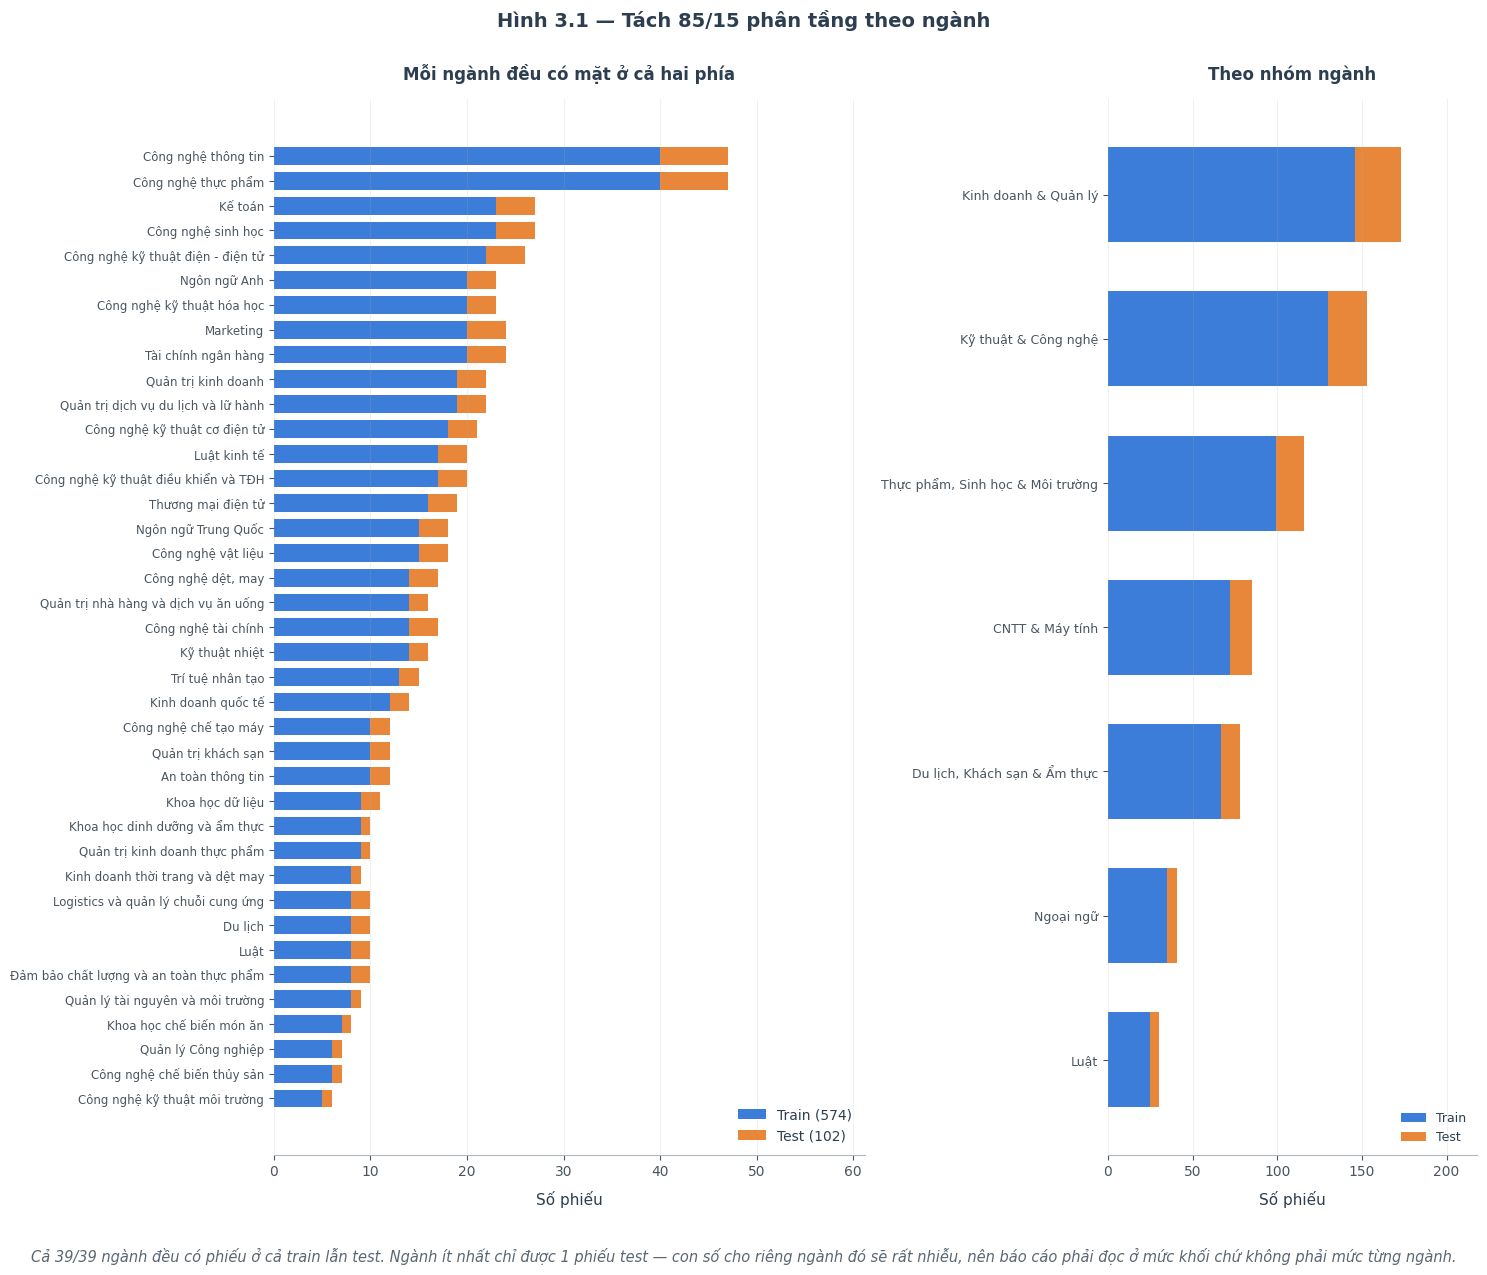

In [4]:
# ═══════════ HÌNH 3.1 — Tách theo ngành ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, cao_theo_dong(len(kt))),
                             gridspec_kw={"width_ratios": [1.6, 1]})
k = kt.sort_values("train")
yy = np.arange(len(k))
a1.barh(yy, k.train, color=C_XANH, height=.72, label=f"Train ({len(tr)})")
a1.barh(yy, k.test, left=k.train, color=C_CAM, height=.72, label=f"Test ({len(te)})")
a1.set_yticks(yy); a1.set_yticklabels(list(k.nganh), fontsize=8.5)
a1.set_xlabel("Số phiếu"); a1.set_title("Mỗi ngành đều có mặt ở cả hai phía", fontsize=12)
cho_chu_giai(a1, phan=.24)
a1.legend(loc="lower right", framealpha=.95)
a1.grid(axis="y", alpha=0)

kn = pd.DataFrame({"train": tr.ma_khoi.value_counts(),
                   "test": te.ma_khoi.value_counts()}).fillna(0).astype(int).sort_index()
# Cột NGANG: tên nhóm dài, xoay chữ thì luôn chồng nhau
kn = kn.sort_values("train")
yy2 = np.arange(len(kn))
a2.barh(yy2, kn.train, color=C_XANH, height=.66, label="Train")
a2.barh(yy2, kn.test, left=kn.train, color=C_CAM, height=.66, label="Test")
a2.set_yticks(yy2)
a2.set_yticklabels([TEN_NHOM[i] for i in kn.index], fontsize=9)
a2.set_xlabel("Số phiếu"); a2.set_title("Theo nhóm ngành", fontsize=12)
a2.grid(axis="y", alpha=0)
cho_chu_giai(a2, phan=.20)
a2.legend(loc="lower right", fontsize=9, framealpha=.95)

fig.suptitle(f"Hình 3.1 — Tách {100-TI_LE_TEST*100:.0f}/{TI_LE_TEST*100:.0f}"
             " phân tầng theo ngành", fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_3_1_tach.png",
    f"Cả {kt.shape[0]}/39 ngành đều có phiếu ở cả train lẫn test. Ngành ít nhất chỉ được "
    f"{int(kt.test.min())} phiếu test — con số cho riêng ngành đó sẽ rất nhiễu, nên báo cáo phải "
    "đọc ở mức khối chứ không phải mức từng ngành.")
plt.show()

   💾 hinh_3_2_folds.png


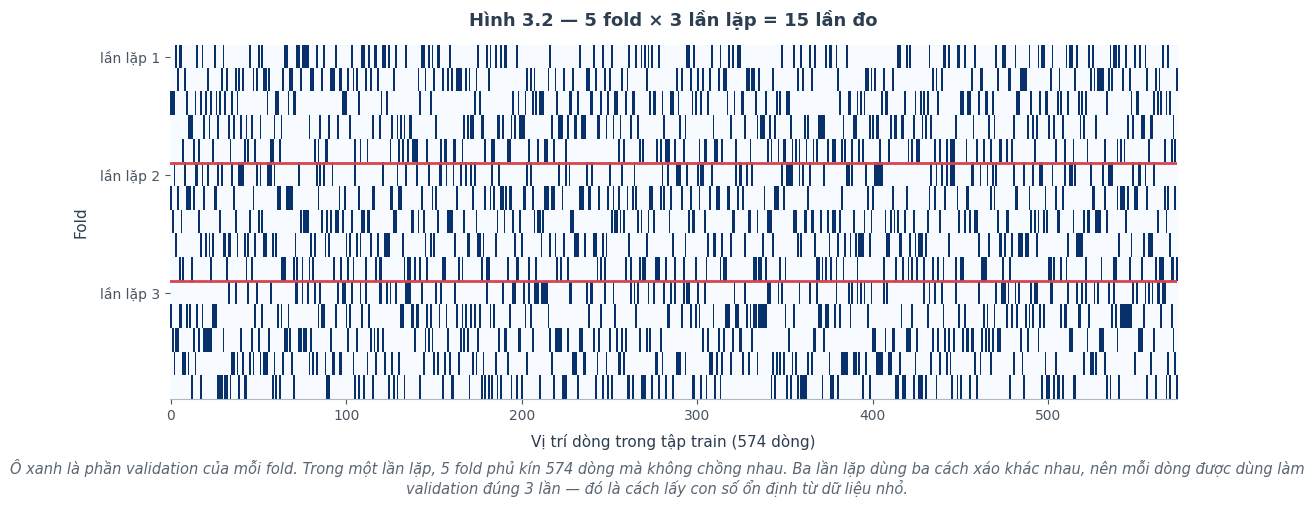

In [5]:
# ═══════════ HÌNH 3.2 — Cấu trúc 15 fold ═══════════
fig, ax = plt.subplots(figsize=(13, 4.6))
M_ = np.zeros((len(folds), len(tr)))
for i, f in enumerate(folds):
    M_[i, f["val_idx"]] = 1
ax.imshow(M_, aspect="auto", cmap="Blues", interpolation="nearest")
ax.set_xlabel(f"Vị trí dòng trong tập train ({len(tr)} dòng)")
ax.set_ylabel("Fold")
ax.set_yticks(range(0, len(folds), N_SPLITS))
ax.set_yticklabels([f"lần lặp {i+1}" for i in range(N_REPEATS)])
for i in range(1, N_REPEATS):
    ax.axhline(i * N_SPLITS - .5, color=C_THAT, lw=2)
ax.set_title(f"Hình 3.2 — {N_SPLITS} fold × {N_REPEATS} lần lặp = {len(folds)} lần đo")
ax.grid(alpha=0)
luu(fig, OUT, "hinh_3_2_folds.png",
    f"Ô xanh là phần validation của mỗi fold. Trong một lần lặp, {N_SPLITS} fold phủ kín "
    f"{len(tr)} dòng mà không chồng nhau. Ba lần lặp dùng ba cách xáo khác nhau, nên mỗi dòng "
    f"được dùng làm validation đúng {N_REPEATS} lần — đó là cách lấy con số ổn định từ dữ liệu nhỏ.")
plt.show()

## 3. Xuất và khoá tập test

In [6]:
tr.to_csv(OUT / "khaosat_train.csv", index=False)
te.to_csv(OUT / "khaosat_test_KHOA.csv", index=False)
kt.to_csv(OUT / "phan_bo_train_test.csv")

tom_tat("GIAI ĐOẠN 3 — TÁCH TRAIN / TEST", [
    f"Phiếu sạch             {len(d)}",
    f"   → TRAIN             {len(tr)}   ({len(tr)/len(d):.0%})   dùng cho Giai đoạn 4–9",
    f"   → TEST              {len(te)}   ({len(te)/len(d):.0%})   KHOÁ tới Giai đoạn 10",
    "",
    f"Phân tầng theo         ngành (39 lớp)",
    f"Ngành ở cả hai phía    {kt.shape[0]}/39",
    f"Phiếu test ít nhất     {int(kt.test.min())} phiếu/ngành",
    "",
    f"Cross-validation       {N_SPLITS} fold × {N_REPEATS} lần lặp = {len(folds)} lần đo",
    f"Mỗi fold validation    {min(kich_co)}–{max(kich_co)} dòng",
])
print(f"\n⚠️  khaosat_test_KHOA.csv KHÔNG được đọc ở Giai đoạn 4–9.")
print(f"    Chỉ Giai đoạn 10 mở nó, đúng MỘT lần.")
print(f"\n✅ khaosat_train.csv · khaosat_test_KHOA.csv · cv_folds.json · 2 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                      GIAI ĐOẠN 3 — TÁCH TRAIN / TEST                       ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Phiếu sạch             676                                                 ║
║    → TRAIN             574   (85%)   dùng cho Giai đoạn 4–9                ║
║    → TEST              102   (15%)   KHOÁ tới Giai đoạn 10                 ║
║                                                                            ║
║ Phân tầng theo         ngành (39 lớp)                                      ║
║ Ngành ở cả hai phía    39/39                                               ║
║ Phiếu test ít nhất     1 phiếu/ngành                                       ║
║                                                                            ║
║ Cross-validation       5 fold × 3 lần lặp = 15 lần đo                      ║
║ Mỗi fold validation    114–115 dòng               